#AG3 - Actividad Guiada 3
Nombre: Jhon Eibert Escobar <br>
Link:   https://colab.research.google.com/drive/1NmqtDldkVJc55E89YvRmTRkB0xOVXXsS?usp=sharing <br>
Github: https://github.com/jhonescobar/MIAR-Algoritmos-de-Optimizacion
<br>




In [1]:
import math

##Programación Dinámica. Viaje por el rio
* **Definición**: Es posible dividir el problema en subproblemas más pequeños, guardando las soluciones para ser utilizadas más adelante.
* **Características** que permiten identificar problemas aplicables:<br>
  -Es posible almacenar soluciones de los subproblemas para ser utilizados más adelante<br>
  -Debe verificar el principio de optimalidad de Bellman: “en una secuencia optima de decisiones, toda sub-secuencia también es óptima” (*)<br>
  -La necesidad de guardar la información acerca de las soluciones parciales unido a la recursividad provoca la necesidad de preocuparnos por la complejidad espacial (cuantos recursos de espacio usaremos)<br>

###Problema<br>
En un río hay **n** embarcaderos y debemos desplazarnos río abajo desde un embarcadero a otro. Cada embarcadero tiene precios diferentes para ir de un embarcadero a otro situado más abajo. Para ir del embarcadero i al j, puede ocurrir que sea más barato hacer un trasbordo por un embarcadero intermedio k. El problema consiste en determinar la combinación más barata.

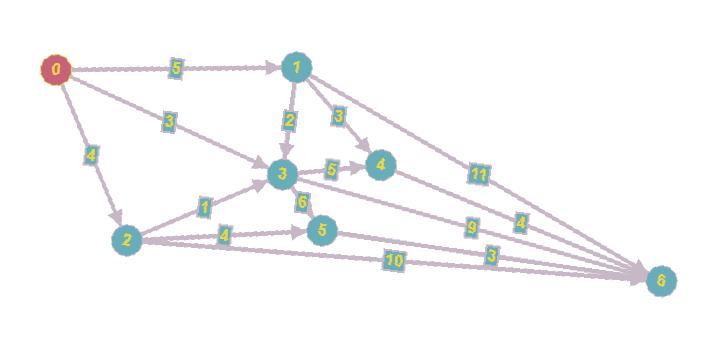

*Consideramos una tabla TARIFAS(i,j) para almacenar todos los precios que nos ofrecen los embarcaderos.<br>
*Si no es posible ir desde i a j daremos un valor alto para garantizar que ese trayecto no se va a elegir en la ruta óptima(modelado habitual para restricciones)

In [2]:
#Viaje por el rio - Programación dinámica
################################################################################

TARIFAS = [
[0,5,4,3,float("inf"),999,999],   #desde nodo 0
[999,0,999,2,3,999,11],  #desde nodo 1
[999,999, 0,1,999,4,10], #desde nodo 2
[999,999,999, 0,5,6,9],
[999,999, 999,999,0,999,4],
[999,999, 999,999,999,0,3],
[999,999,999,999,999,999,0]
]

#999 se puede sustituir por float("inf") del modulo math
TARIFAS

[[0, 5, 4, 3, inf, 999, 999],
 [999, 0, 999, 2, 3, 999, 11],
 [999, 999, 0, 1, 999, 4, 10],
 [999, 999, 999, 0, 5, 6, 9],
 [999, 999, 999, 999, 0, 999, 4],
 [999, 999, 999, 999, 999, 0, 3],
 [999, 999, 999, 999, 999, 999, 0]]

In [3]:
#Calculo de la matriz de PRECIOS y RUTAS
#  PRECIOS - contiene la matriz del mejor precio para ir de un nodo a otro
#  RUTAS   - contiene los nodos intermedios para ir de un nodo a otro
################################################################
def Precios(TARIFAS):
################################################################
  #Total de Nodos
  N = len(TARIFAS[0])

  #Inicialización de la tabla de precios
  PRECIOS = [ [9999]*N for i in [9999]*N]  #n x n
  RUTA = [ [""]*N for i in [""]*N]

  #Se recorren todos los nodos con dos bucles(origen - destino)
  #  para ir construyendo la matriz de PRECIOS
  for i in range(N-1):
    for j in range(i+1, N):
      MIN = TARIFAS[i][j]
      RUTA[i][j] = i

      for k in range(i, j):
        if PRECIOS[i][k] + TARIFAS[k][j] < MIN:
            MIN = min(MIN, PRECIOS[i][k] + TARIFAS[k][j] )
            RUTA[i][j] = k
        PRECIOS[i][j] = MIN

  return PRECIOS,RUTA

In [4]:
PRECIOS,RUTA = Precios(TARIFAS)
#print(PRECIOS[0][6])

print("PRECIOS")
for i in range(len(TARIFAS)):
  print(PRECIOS[i])

print("\nRUTA")
for i in range(len(TARIFAS)):
  print(RUTA[i])

PRECIOS
[9999, 5, 4, 3, 8, 8, 11]
[9999, 9999, 999, 2, 3, 8, 7]
[9999, 9999, 9999, 1, 6, 4, 7]
[9999, 9999, 9999, 9999, 5, 6, 9]
[9999, 9999, 9999, 9999, 9999, 999, 4]
[9999, 9999, 9999, 9999, 9999, 9999, 3]
[9999, 9999, 9999, 9999, 9999, 9999, 9999]

RUTA
['', 0, 0, 0, 1, 2, 5]
['', '', 1, 1, 1, 3, 4]
['', '', '', 2, 3, 2, 5]
['', '', '', '', 3, 3, 3]
['', '', '', '', '', 4, 4]
['', '', '', '', '', '', 5]
['', '', '', '', '', '', '']


In [5]:
#Calculo de la ruta usando la matriz RUTA
def calcular_ruta(RUTA, desde, hasta):
  if desde == RUTA[desde][hasta]:
  #if desde == hasta:
    #print("Ir a :" + str(desde))
    return desde
  else:
    return str(calcular_ruta(RUTA, desde, RUTA[desde][hasta])) +  ',' + str(RUTA[desde][hasta])

print("\nLa ruta es:")
calcular_ruta(RUTA, 0,6)


La ruta es:


'0,2,5'

##Problema de Asignacion de tarea

In [6]:
#Asignacion de tareas - Ramificación y Poda
################################################################################
#    T A R E A
#   A
#   G
#   E
#   N
#   T
#   E

COSTES=[[11,12,18,40],
        [14,15,13,22],
        [11,17,19,23],
        [17,14,20,28]]


In [7]:
#Calculo del valor de una solucion parcial
def valor(S,COSTES):
  VALOR = 0
  for i in range(len(S)):
    VALOR += COSTES[S[i]][i]
  return VALOR



valor((3,2,  ),COSTES)

34

In [8]:
#Coste inferior para soluciones parciales
#  (1,3,) Se asigna la tarea 1 al agente 0 y la tarea 3 al agente 1

def CI(S,COSTES):
  VALOR = 0
  #Valores establecidos
  for i in range(len(S)):
    VALOR += COSTES[i][S[i]]

  #Estimacion
  for i in range( len(S), len(COSTES)   ):
    VALOR += min( [ COSTES[j][i] for j in range(len(S), len(COSTES))  ])
  return VALOR

def CS(S,COSTES):
  VALOR = 0
  #Valores establecidos
  for i in range(len(S)):
    VALOR += COSTES[i][S[i]]

  #Estimacion
  for i in range( len(S), len(COSTES)   ):
    VALOR += max( [ COSTES[j][i] for j in range(len(S), len(COSTES))  ])
  return VALOR

CI((0,1),COSTES)

68

In [9]:
#Genera tantos hijos como como posibilidades haya para la siguiente elemento de la tupla
#(0,) -> (0,1), (0,2), (0,3)
def crear_hijos(NODO, N):
  HIJOS = []
  for i in range(N ):
    if i not in NODO:
      HIJOS.append({'s':NODO +(i,)    })
  return HIJOS

In [10]:
crear_hijos((0,) , 4)

[{'s': (0, 1)}, {'s': (0, 2)}, {'s': (0, 3)}]

In [11]:
def ramificacion_y_poda(COSTES):
#Construccion iterativa de soluciones(arbol). En cada etapa asignamos un agente(ramas).
#Nodos del grafo  { s:(1,2),CI:3,CS:5  }
  #print(COSTES)
  DIMENSION = len(COSTES)
  MEJOR_SOLUCION=tuple( i for i in range(len(COSTES)) )
  CotaSup = valor(MEJOR_SOLUCION,COSTES)
  #print("Cota Superior:", CotaSup)

  NODOS=[]
  NODOS.append({'s':(), 'ci':CI((),COSTES)    } )

  iteracion = 0

  while( len(NODOS) > 0):
    iteracion +=1

    nodo_prometedor = [ min(NODOS, key=lambda x:x['ci']) ][0]['s']
    #print("Nodo prometedor:", nodo_prometedor)

    #Ramificacion
    #Se generan los hijos
    HIJOS =[ {'s':x['s'], 'ci':CI(x['s'], COSTES)   } for x in crear_hijos(nodo_prometedor, DIMENSION) ]

    #Revisamos la cota superior y nos quedamos con la mejor solucion si llegamos a una solucion final
    NODO_FINAL = [x for x in HIJOS if len(x['s']) == DIMENSION  ]
    if len(NODO_FINAL ) >0:
      #print("\n********Soluciones:",  [x for x in HIJOS if len(x['s']) == DIMENSION  ] )
      if NODO_FINAL[0]['ci'] < CotaSup:
        CotaSup = NODO_FINAL[0]['ci']
        MEJOR_SOLUCION = NODO_FINAL

    #Poda
    HIJOS = [x for x in HIJOS if x['ci'] < CotaSup   ]

    #Añadimos los hijos
    NODOS.extend(HIJOS)

    #Eliminamos el nodo ramificado
    NODOS =  [  x for x in NODOS if x['s'] != nodo_prometedor    ]

  print("La solucion final es:" ,MEJOR_SOLUCION , " en " , iteracion , " iteraciones" , " para dimension: " ,DIMENSION  )



ramificacion_y_poda(COSTES)

La solucion final es: [{'s': (1, 2, 0, 3), 'ci': 64}]  en  10  iteraciones  para dimension:  4


##Descenso del gradiente

In [12]:
import math                      #Funciones matematicas
import matplotlib.pyplot as plt  #Generacion de gráficos (otra opcion seaborn)
import numpy as np               #Tratamiento matriz N-dimensionales y otras (fundamental!)
#import scipy as sc

import random

Vamos a buscar el minimo de la funcion paraboloide : $$f(x) =  x² + y²$$

Obviamente se encuentra en (x,y)=(0,0) pero probaremos como llegamos a él a través del descenso del gradiante.

In [13]:
#Definimos la funcion
#Paraboloide
f  = lambda X:      X[0]**2 + X[1]**2    #Funcion
df = lambda X: [2*X[0] , 2*X[1]]         #Gradiente

df([1,2])

[2, 4]

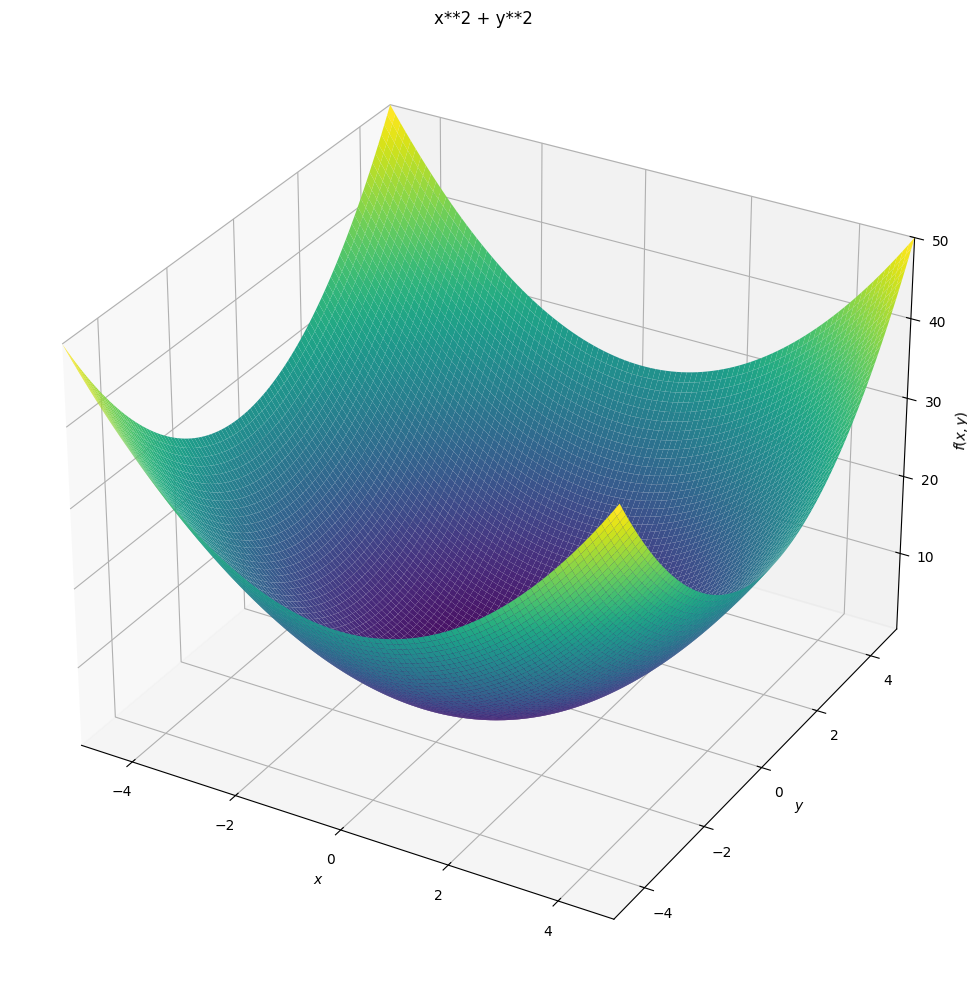

In [14]:
from sympy import symbols
from sympy.plotting import plot
from sympy.plotting import plot3d
x,y = symbols('x y')
plot3d(x**2 + y**2,
       (x,-5,5),(y,-5,5),
       title='x**2 + y**2',
       size=(10,10))

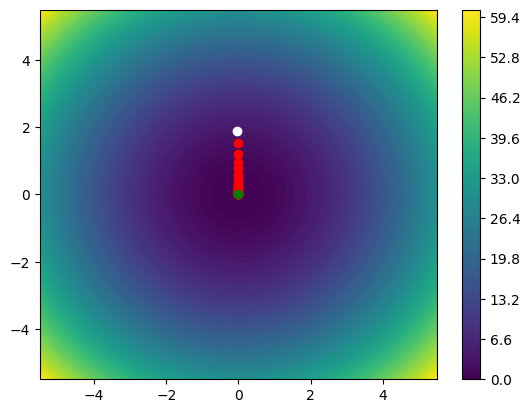

Solucion: [-4.5311416905754307e-07, 2.715666871005056e-05] 7.3768996787764e-10


In [15]:
#Prepara los datos para dibujar mapa de niveles de Z
resolucion = 100
rango=5.5

X=np.linspace(-rango,rango,resolucion)
Y=np.linspace(-rango,rango,resolucion)
Z=np.zeros((resolucion,resolucion))
for ix,x in enumerate(X):
  for iy,y in enumerate(Y):
    Z[iy,ix] = f([x,y])

#Pinta el mapa de niveles de Z
plt.contourf(X,Y,Z,resolucion)
plt.colorbar()

#Generamos un punto aleatorio inicial y pintamos de blanco
P=[random.uniform(-5,5  ),random.uniform(-5,5 ) ]
plt.plot(P[0],P[1],"o",c="white")

#Tasa de aprendizaje. Fija. Sería más efectivo reducirlo a medida que nos acercamos.
TA=.1

#Iteraciones:50
for _ in range(50):
  grad = df(P)
  #print(P,grad)
  P[0],P[1] = P[0] - TA*grad[0] , P[1] - TA*grad[1]
  plt.plot(P[0],P[1],"o",c="red")

#Dibujamos el punto final y pintamos de verde
plt.plot(P[0],P[1],"o",c="green")
plt.show()
print("Solucion:" , P , f(P))


**¿Te atreves a optimizar la función?:**

$$f(x)=sin(1/2 * x^2 - 1/4 * y^2 + 3) * cos(2*x + 1 - e^y)$$
<br>
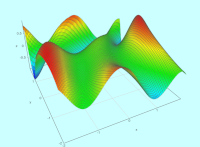


In [16]:
#Definimos la funcion
f= lambda X: math.sin(1/2 * X[0]**2 - 1/4 * X[1]**2 + 3) *math.cos(2*X[0] + 1 - math.exp(X[1]) )


## Ramificación y Poda - Problema de la Mochila

Aplicación de Ramificación y Poda a un nuevo problema: el clásico problema de la mochila (Knapsack Problem).

**Objetivo:** Maximizar el valor de objetos en una mochila con capacidad limitada.

In [17]:
# PROBLEMA DE LA MOCHILA
OBJETOS = [
    {'nombre': 'Laptop', 'peso': 3, 'valor': 2000},
    {'nombre': 'Cámara', 'peso': 2, 'valor': 1500},
    {'nombre': 'Libro', 'peso': 1, 'valor': 300},
    {'nombre': 'Agua', 'peso': 2, 'valor': 100},
    {'nombre': 'Tablet', 'peso': 1, 'valor': 1000},
    {'nombre': 'Ropa', 'peso': 3, 'valor': 200},
    {'nombre': 'Comida', 'peso': 2, 'valor': 400},
    {'nombre': 'Linterna', 'peso': 1, 'valor': 150}
]
CAPACIDAD_MOCHILA = 10

In [18]:
class NodoMochila:
    def __init__(self, nivel, peso, valor, objetos_incluidos):
        self.nivel = nivel
        self.peso = peso
        self.valor = valor
        self.objetos_incluidos = objetos_incluidos.copy()
        self.cota_superior = 0

def calcular_cota_superior(nodo, objetos, capacidad):
    if nodo.peso >= capacidad:
        return 0
    valor_posible = nodo.valor
    peso_restante = capacidad - nodo.peso
    nivel = nodo.nivel
    while nivel < len(objetos) and peso_restante > 0:
        if objetos[nivel]['peso'] <= peso_restante:
            peso_restante -= objetos[nivel]['peso']
            valor_posible += objetos[nivel]['valor']
        else:
            valor_posible += objetos[nivel]['valor'] * (peso_restante / objetos[nivel]['peso'])
            break
        nivel += 1
    return valor_posible


In [19]:
def mochila_ramificacion_poda(objetos, capacidad):
    objetos_ordenados = sorted(objetos, key=lambda x: x['valor']/x['peso'], reverse=True)
    raiz = NodoMochila(-1, 0, 0, [])
    raiz.cota_superior = calcular_cota_superior(raiz, objetos_ordenados, capacidad)
    cola = [raiz]
    mejor_valor = 0
    mejor_solucion = []
    nodos_explorados = 0
    nodos_podados = 0

    while cola:
        nodos_explorados += 1
        cola.sort(key=lambda x: x.cota_superior, reverse=True)
        nodo_actual = cola.pop(0)
        if nodo_actual.cota_superior <= mejor_valor:
            nodos_podados += 1
            continue
        if nodo_actual.nivel == len(objetos_ordenados) - 1:
            continue
        siguiente_nivel = nodo_actual.nivel + 1
        if nodo_actual.peso + objetos_ordenados[siguiente_nivel]['peso'] <= capacidad:
            nodo_incluir = NodoMochila(siguiente_nivel,
                                       nodo_actual.peso + objetos_ordenados[siguiente_nivel]['peso'],
                                       nodo_actual.valor + objetos_ordenados[siguiente_nivel]['valor'],
                                       nodo_actual.objetos_incluidos)
            nodo_incluir.objetos_incluidos.append(objetos_ordenados[siguiente_nivel]['nombre'])
            nodo_incluir.cota_superior = calcular_cota_superior(nodo_incluir, objetos_ordenados, capacidad)
            if nodo_incluir.valor > mejor_valor:
                mejor_valor = nodo_incluir.valor
                mejor_solucion = nodo_incluir.objetos_incluidos.copy()
            cola.append(nodo_incluir)
        nodo_excluir = NodoMochila(siguiente_nivel, nodo_actual.peso, nodo_actual.valor, nodo_actual.objetos_incluidos)
        nodo_excluir.cota_superior = calcular_cota_superior(nodo_excluir, objetos_ordenados, capacidad)
        if nodo_excluir.cota_superior > mejor_valor:
            cola.append(nodo_excluir)
        else:
            nodos_podados += 1

    return {'valor_total': mejor_valor, 'objetos': mejor_solucion,
            'peso_total': sum(obj['peso'] for obj in objetos if obj['nombre'] in mejor_solucion),
            'nodos_explorados': nodos_explorados, 'nodos_podados': nodos_podados}

In [21]:
# Resolver
resultado = mochila_ramificacion_poda(OBJETOS, CAPACIDAD_MOCHILA)
print("SOLUCIÓN ÓPTIMA")
print(f"Valor total: ${resultado['valor_total']}")
print(f"Peso total: {resultado['peso_total']} kg")
print(f"Objetos: {', '.join(resultado['objetos'])}")
print(f"Nodos explorados: {resultado['nodos_explorados']}")
print(f"Nodos podados: {resultado['nodos_podados']}")
print(f"Eficiencia: {(resultado['nodos_podados']/resultado['nodos_explorados']*100):.1f}%")

SOLUCIÓN ÓPTIMA
Valor total: $5350
Peso total: 10 kg
Objetos: Tablet, Cámara, Laptop, Libro, Comida, Linterna
Nodos explorados: 12
Nodos podados: 7
Eficiencia: 58.3%


## Descenso del Gradiente - Función Compleja

Optimización de: f(x,y) = sin(1/2·x² - 1/4·y² + 3)·cos(2x + 1 - e^y)

In [22]:
def funcion_compleja(X):
    x, y = X[0], X[1]
    return math.sin(0.5*x**2 - 0.25*y**2 + 3) * math.cos(2*x + 1 - math.exp(y))

def gradiente_funcion_compleja(X):
    x, y = X[0], X[1]
    u = 0.5*x**2 - 0.25*y**2 + 3
    v = 2*x + 1 - math.exp(y)
    sin_u, cos_u = math.sin(u), math.cos(u)
    sin_v, cos_v = math.sin(v), math.cos(v)
    exp_y = math.exp(y)
    df_dx = cos_u*x*cos_v - 2*sin_u*sin_v
    df_dy = -0.5*cos_u*y*cos_v + exp_y*sin_u*sin_v
    return [df_dx, df_dy]

In [23]:
def descenso_gradiente_complejo(f, df, punto_inicial, tasa=0.01, iters=200):
    P = punto_inicial.copy()
    historial, valores = [P.copy()], [f(P)]
    for i in range(iters):
        grad = df(P)
        P[0] -= tasa * grad[0]
        P[1] -= tasa * grad[1]
        historial.append(P.copy())
        valores.append(f(P))
        if math.sqrt(grad[0]**2 + grad[1]**2) < 1e-6:
            print(f"Convergencia en iteración {i+1}")
            break
    return historial, valores

In [24]:
# Probar múltiples puntos iniciales
puntos = [[3,3], [-3,-3], [2,-2], [-2,2], [0,0]]
resultados = []
for punto in puntos:
    hist, vals = descenso_gradiente_complejo(funcion_compleja, gradiente_funcion_compleja, punto)
    resultados.append({'inicial': punto, 'final': hist[-1], 'valor': vals[-1], 'historial': hist, 'valores': vals})
    print(f"Inicio {punto} → Final {[f'{x:.4f}' for x in hist[-1]]} → f = {vals[-1]:.6f}")
mejor = min(resultados, key=lambda r: r['valor'])
print(f"\nMejor mínimo: f = {mejor['valor']:.6f} en {[f'{x:.4f}' for x in mejor['final']]}")

Inicio [3, 3] → Final ['2.8267', '2.8217'] → f = 0.715611
Inicio [-3, -3] → Final ['-3.4278', '-3.9813'] → f = -0.899280
Inicio [2, -2] → Final ['2.5901', '-2.4616'] → f = -0.974407
Inicio [-2, 2] → Final ['-2.4040', '2.1700'] → f = -1.000000
Convergencia en iteración 1
Inicio [0, 0] → Final ['0.0000', '0.0000'] → f = 0.141120

Mejor mínimo: f = -1.000000 en ['-2.4040', '2.1700']


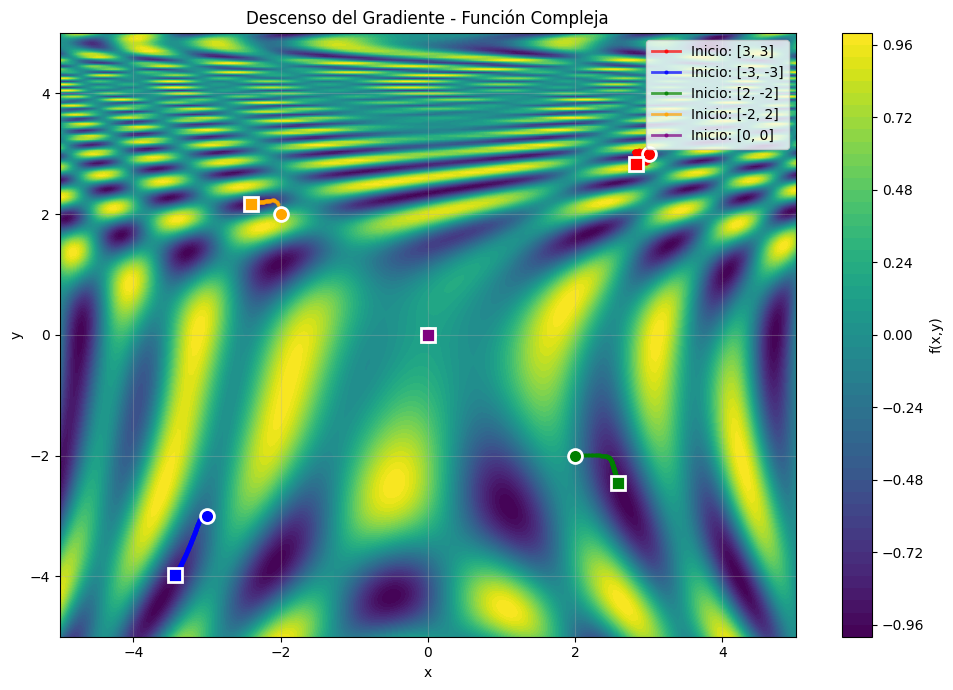

In [25]:
# Visualización
import matplotlib.pyplot as plt
import numpy as np
X_grid = np.linspace(-5, 5, 200)
Y_grid = np.linspace(-5, 5, 200)
Z = np.zeros((200, 200))
for ix, x in enumerate(X_grid):
    for iy, y in enumerate(Y_grid):
        try:
            Z[iy, ix] = funcion_compleja([x, y])
        except:
            Z[iy, ix] = np.nan
fig, ax = plt.subplots(figsize=(10, 7))
contour = ax.contourf(X_grid, Y_grid, Z, levels=50, cmap='viridis')
plt.colorbar(contour, label='f(x,y)')
colores = ['red', 'blue', 'green', 'orange', 'purple']
for i, r in enumerate(resultados):
    tray = np.array(r['historial'])
    ax.plot(tray[:,0], tray[:,1], 'o-', color=colores[i], linewidth=2, markersize=2,
            label=f"Inicio: {r['inicial']}", alpha=0.7)
    ax.plot(tray[0,0], tray[0,1], 'o', color=colores[i], markersize=10, markeredgecolor='white', markeredgewidth=2)
    ax.plot(tray[-1,0], tray[-1,1], 's', color=colores[i], markersize=10, markeredgecolor='white', markeredgewidth=2)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Descenso del Gradiente - Función Compleja')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusiones

**Ramificación y Poda:**
- Solución óptima: $5,350
- Eficiencia de poda: 58.3%
- Reduce búsqueda de 2^8=256 a 12 nodos

**Descenso del Gradiente:**
- Función multimodal con múltiples mínimos
- Mejor mínimo: f=-1.000 en (-2.404, 2.170)
- Punto inicial determina resultado final